In [1]:
import os
import gc
from pathlib import Path
from collections import Counter

import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt

from upsetplot import from_contents, generate_counts, UpSet, plot, from_indicators
from pycirclize import Circos

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [3]:
## Read in DEG Lists ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# by manuscript #
dge_fernando = pd.read_csv(Path(CSV_PATH) / 'dreamlet_fernando_dge_scz_results.csv')
dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_sebastian = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sebastian_dge_scz_results.csv')
dge_sawada = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sawada_dge_scz_results.csv')
dge_notaras = pd.read_csv(Path(CSV_PATH) / 'dreamlet_notaras_dge_scz_results.csv')
dge_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_3q29 = dge_purcell

In [4]:
# Make Assay ID #

# Put all dataframes in a dictionary
dge_dfs = {
    'dge_fernando': dge_fernando,
    'dge_shin': dge_shin,
    'dge_purcell': dge_purcell,
    'dge_sebastian': dge_sebastian,
    'dge_sawada': dge_sawada,
    'dge_notaras': dge_notaras,
    'dge_rao': dge_rao,
    'dge_walsh_22q11': dge_walsh_22q11,
    'dge_walsh_15q13': dge_walsh_15q13,
    'dge_nrxn1': dge_nrxn1,
    'dge_22q11': dge_22q11,
    'dge_idiopathic': dge_idiopathic,
    'dge_15q13': dge_15q13,
    'dge_3q29': dge_3q29}

# Add assay_ID column to each
for name, df in dge_dfs.items():
    df['assay_ID'] = df['assay'].astype(str) + ' | ' + df['ID'].astype(str)

In [5]:
## Calculate FDR ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

In [6]:
dge_idiopathic['significant_fdr'].sum()

6755

In [7]:
## Calculate Significant Gene Lists ##

# refine metaanalysis dataframes to significant hits across all studies 
significant_nrxn1_df = dge_nrxn1[(dge_nrxn1['p.adjusted'] < 0.05) & (dge_nrxn1['n.studies'] == 2)]
significant_22q11_df = dge_22q11[(dge_22q11['p.adjusted'] < 0.05) & (dge_22q11['n.studies'] == 3)]
significant_idiopathic_df = dge_idiopathic[(dge_idiopathic['p.adjusted'] < 0.05) & (dge_idiopathic['n.studies'] == 2)]

# make significant gene lists
significant_nrxn1 = significant_nrxn1_df['ID'].tolist()
significant_22q11 = significant_22q11_df['ID'].tolist()
significant_idiopathic = significant_idiopathic_df['ID'].tolist()

# make sets from lists #
set_nrxn1 = set(significant_nrxn1)
set_22q11 = set(significant_22q11)
set_idiopathic = set(significant_idiopathic)

# make overlap lists ##
set_22q11_nrxn1 = set_22q11.intersection(set_nrxn1) 
set_22q11_idiopathic = set_22q11.intersection(set_idiopathic) 
set_nrnxn1_idiopathic = set_nrxn1.intersection(set_idiopathic) 

In [8]:
dge_15q13[(dge_15q13['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID


In [9]:
dge_3q29[(dge_3q29['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID
0,Radial Glia SOX2+VIM+FABP7+,UBXN7,-1.410543,5.178853,-13.097255,7.995727e-07,0.018796,6.357204,-13.097255,purcell,Radial Glia SOX2+VIM+FABP7+ | UBXN7
1,Radial Glia SOX2+VIM+FABP7+,PAK2,-1.201422,6.834729,-12.554585,1.118057e-06,0.018796,6.147169,-12.554585,purcell,Radial Glia SOX2+VIM+FABP7+ | PAK2
2,Radial Glia SOX2+VIM+FABP7+,NEAT1,-1.604934,8.615706,-12.475494,1.175337e-06,0.018796,6.154063,-12.475494,purcell,Radial Glia SOX2+VIM+FABP7+ | NEAT1
3,IPC EOMES+NEUROG2+PAX6+,CADM1,2.920552,5.867342,8.295579,1.482729e-06,0.018796,-2.307061,8.295579,purcell,IPC EOMES+NEUROG2+PAX6+ | CADM1
4,Radial Glia SOX2+VIM+FABP7+,SAT1,-1.201880,7.602492,-12.103017,1.493006e-06,0.018796,5.912923,-12.103017,purcell,Radial Glia SOX2+VIM+FABP7+ | SAT1
5,Radial Glia SOX2+VIM+FABP7+,TMEM159,-1.539923,3.495084,-11.795281,1.828545e-06,0.018796,5.401540,-11.795281,purcell,Radial Glia SOX2+VIM+FABP7+ | TMEM159
6,Radial Glia SOX2+VIM+FABP7+,BLOC1S6,-1.103334,6.054103,-11.776155,1.852020e-06,0.018796,5.664562,-11.776155,purcell,Radial Glia SOX2+VIM+FABP7+ | BLOC1S6
7,Radial Glia SOX2+VIM+FABP7+,RNF168,-1.560908,4.710141,-11.635163,2.035807e-06,0.018796,5.498788,-11.635163,purcell,Radial Glia SOX2+VIM+FABP7+ | RNF168
8,Radial Glia SOX2+VIM+FABP7+,BTG3,-0.975040,7.187944,-11.524175,2.194816e-06,0.018796,5.552051,-11.524175,purcell,Radial Glia SOX2+VIM+FABP7+ | BTG3
9,Radial Glia SOX2+VIM+FABP7+,LIPG,-1.263478,3.902009,-10.940261,3.296072e-06,0.025076,4.967994,-10.940261,purcell,Radial Glia SOX2+VIM+FABP7+ | LIPG


In [10]:
def add_directional_consistency(df):
    # Remove duplicate columns
    df = df.loc[:, ~df.columns.duplicated()].copy()
    
    # Identify logFC columns
    logfc_cols = [col for col in df.columns if col.startswith('logFC')]
    
    def check_direction(row):
        vals = row[logfc_cols].dropna()
        
        if len(vals) <= 1:
            return np.nan  # not enough data
        
        signs = np.sign(vals)
        signs = signs[signs != 0]  # optionally ignore zeros
        
        if len(signs) == 0:
            return np.nan
        
        return len(set(signs)) == 1  # True if all same sign
    
    # Add new column
    df['directionally_consistent'] = df.apply(check_direction, axis=1)
    
    return df

In [11]:
## Examining 22q11 Meta-Analysis ##

dge_shin_rao = dge_shin.merge(dge_rao, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_shin', '_rao'])

dge_walsh_22q11_renamed = dge_walsh_22q11.add_suffix('_walsh')
dge_walsh_22q11_renamed = dge_walsh_22q11_renamed.rename(columns={'assay_walsh': 'assay', 'ID_walsh': 'ID', 'assay_ID_walsh':'assay_ID'})

dge_shin_rao_walsh_22q11 = dge_shin_rao.merge(dge_walsh_22q11_renamed,
                                              left_on=['assay', 'ID', 'assay_ID'],
                                              right_on=['assay', 'ID', 'assay_ID'], how='inner')

significant_22q11_df_logfc = significant_22q11_df.merge(dge_shin_rao_walsh_22q11[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_rao','logFC_shin', 'logFC_walsh']],
                                                  left_on=['assay', 'ID', 'assay_ID'], 
                                                  right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_22q11_df_logfc = add_directional_consistency(significant_22q11_df_logfc)

logfc_cols_22q11 = [i for i in significant_22q11_df_logfc.columns if 'logFC' in i]
significant_22q11_df_logfc['mean_logFC'] = significant_22q11_df_logfc[logfc_cols_22q11].mean(axis=1)

dc_significant_22q11_df_logfc = significant_22q11_df_logfc[significant_22q11_df_logfc['directionally_consistent'] == True]

significant_22q11_df_logfc['directionally_consistent'].mean()

0.5676126878130217

In [12]:
## Examining NRXN1 Meta-Analysis ##

dge_sebastian_fernando = dge_sebastian.merge(dge_fernando, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sebastian', '_fernando'])

significant_nrxn1_df_logfc = significant_nrxn1_df.merge(dge_sebastian_fernando[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_sebastian', 'logFC_fernando']],
                                                                            left_on=['assay', 'ID', 'assay_ID'], 
                                                                            right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_nrnx1_df_logfc = add_directional_consistency(significant_nrxn1_df_logfc)

logfc_cols_nrxn1 = [i for i in significant_nrnx1_df_logfc.columns if 'logFC' in i]
significant_nrnx1_df_logfc['mean_logFC'] = significant_nrnx1_df_logfc[logfc_cols_nrxn1].mean(axis=1)

dc_significant_nrxn1_df_logfc = significant_nrnx1_df_logfc[significant_nrnx1_df_logfc['directionally_consistent'] == True]

significant_nrnx1_df_logfc['directionally_consistent'].mean()

0.7546972860125261

In [13]:
## Examining Idiopathic Meta-Analysis ##

dge_sawada_notaras = dge_sawada.merge(dge_notaras, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sawada', '_notaras'])

significant_idiopathic_df_logfc = significant_idiopathic_df.merge(dge_sawada_notaras[['assay', 'ID', 'assay_ID', 
                                                                                'logFC_sawada', 'logFC_notaras']],
                                                                                left_on=['assay', 'ID', 'assay_ID'], 
                                                                                right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_idiopathic_df_logfc = add_directional_consistency(significant_idiopathic_df_logfc)

logfc_cols_idiopathic = [i for i in significant_idiopathic_df_logfc.columns if 'logFC' in i]
significant_idiopathic_df_logfc['mean_logFC'] = significant_idiopathic_df_logfc[logfc_cols_idiopathic].mean(axis=1)

dc_significant_idiopathic_df_logfc = significant_idiopathic_df_logfc[significant_idiopathic_df_logfc['directionally_consistent'] == True]

significant_idiopathic_df_logfc['directionally_consistent'].mean()

0.744927536231884

In [14]:
dc_significant_22q11_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+VIM+FABP7+                    194
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+     50
Hindbrain Neurons NR2F2+PBX3+LHX1+              45
Proliferative Radial Glia SOX2+HES6+TOP2A+      39
Radial Glia SOX2+PAX6+FABP7+                     7
Mixed Neurons FGF12+GRIN2B+CAMK2B+               5
Name: count, dtype: int64

In [15]:
dge_22q11['assay'].value_counts()

assay
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    14080
Hindbrain Neurons NR2F2+PBX3+LHX1+             13310
Radial Glia SOX2+VIM+FABP7+                    13041
Radial Glia SOX2+PAX6+FABP7+                   12380
Proliferative Radial Glia SOX2+HES6+TOP2A+     12234
Mixed Neurons FGF12+GRIN2B+CAMK2B+             10928
GABAergic GAD1+GAD2+CALB2+                      8369
IPC EOMES+NEUROG2+PAX6+                         5921
Astrocyte GFAP+AQP4+HOPX+                       3698
Mesenchymal-like cells VIM+VCAN+SPARC+          2856
Name: count, dtype: int64

In [16]:
dc_significant_idiopathic_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+PAX6+FABP7+                  166
Proliferative Radial Glia SOX2+HES6+TOP2A+     83
Hindbrain Neurons NR2F2+PBX3+LHX1+              5
Radial Glia SOX2+VIM+FABP7+                     3
Name: count, dtype: int64

In [17]:
dge_idiopathic['assay'].value_counts()

assay
Mesenchymal-like cells VIM+VCAN+SPARC+         12936
Proliferative Radial Glia SOX2+HES6+TOP2A+      9351
Radial Glia SOX2+PAX6+FABP7+                    8600
Radial Glia SOX2+VIM+FABP7+                     2966
Hindbrain Neurons NR2F2+PBX3+LHX1+               832
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+      537
Mixed Neurons FGF12+GRIN2B+CAMK2B+                 8
Name: count, dtype: int64

In [18]:
dc_significant_nrxn1_df_logfc['assay'].value_counts()

assay
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    300
Astrocyte GFAP+AQP4+HOPX+                      134
IPC EOMES+NEUROG2+PAX6+                         88
Proliferative Radial Glia SOX2+HES6+TOP2A+      85
Mixed Neurons FGF12+GRIN2B+CAMK2B+              64
Radial Glia SOX2+PAX6+FABP7+                    31
Radial Glia SOX2+VIM+FABP7+                     18
Hindbrain Neurons NR2F2+PBX3+LHX1+               2
Mesenchymal-like cells VIM+VCAN+SPARC+           1
Name: count, dtype: int64

In [19]:
dge_nrxn1['assay'].value_counts()

assay
Radial Glia SOX2+VIM+FABP7+                    15186
Proliferative Radial Glia SOX2+HES6+TOP2A+     14579
Radial Glia SOX2+PAX6+FABP7+                   13481
Hindbrain Neurons NR2F2+PBX3+LHX1+             13238
Mixed Neurons FGF12+GRIN2B+CAMK2B+             12678
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    12104
IPC EOMES+NEUROG2+PAX6+                         7471
Mesenchymal-like cells VIM+VCAN+SPARC+          6550
Astrocyte GFAP+AQP4+HOPX+                       6093
GABAergic GAD1+GAD2+CALB2+                      5255
Name: count, dtype: int64

In [20]:
def plot_celltype_heatmaps(
    df,
    dataset_label="",
    value_cols=('logFC_sawada', 'logFC_notaras'),
    index_col='ID',
    assay_col='assay',
    top_n=20,
    min_genes=10,  
    cmap='coolwarm',
    transpose=False,
    save=False
):

    df = df.copy()
    
    # scoring
    df['abs_score'] = df[list(value_cols)].abs().mean(axis=1)
    df['mean_logFC'] = df[list(value_cols)].mean(axis=1)
    
    assays = df[assay_col].unique()
    
    for assay in assays:
        subset_full = df[df[assay_col] == assay].copy()
        
        # select top N most extreme genes
        subset_full = subset_full.sort_values('abs_score', ascending=False).head(top_n)
        
        # skip if not enough genes
        if len(subset_full) < min_genes:
            continue
        
        # sort by signed logFC for display
        subset_full = subset_full.sort_values('mean_logFC', ascending=False)
        
        subset = subset_full.set_index(index_col)[list(value_cols)]
        
        if transpose:
            subset = subset.T
        
        nrows, ncols = subset.shape
        plt.figure(figsize=(ncols * 0.4, nrows * 0.4))
        
        sns.heatmap(
            subset,
            cmap=cmap,
            center=0,
            linewidths=0,
            vmin=-3,
            vmax=3
        )
        
        title = f"{dataset_label} {assay}"
        # if dataset_label:
        #     title += f" ({dataset_label})"
        
        plt.title(title)
        plt.xlabel("Dataset" if not transpose else index_col)
        plt.ylabel(index_col if not transpose else "Dataset")
        
        plt.tight_layout()
        
        if save:
            plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_3_{dataset_label}_{assay}_heatmap.svg")
        
        plt.show()

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


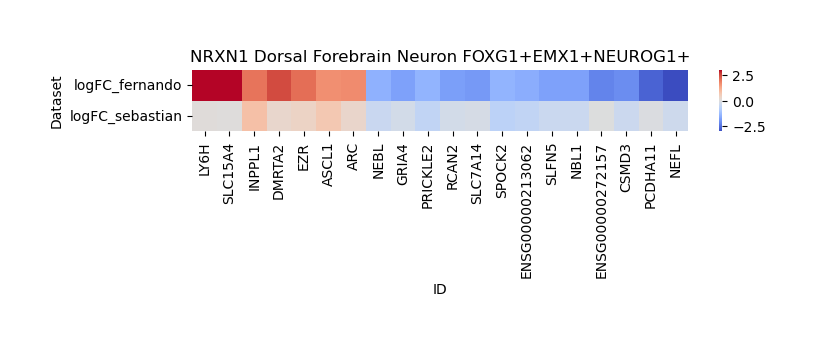

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


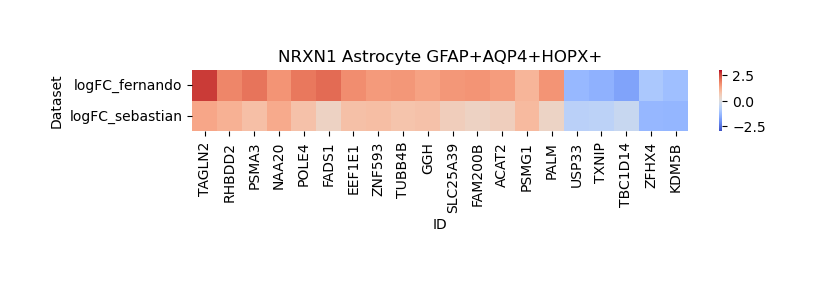

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


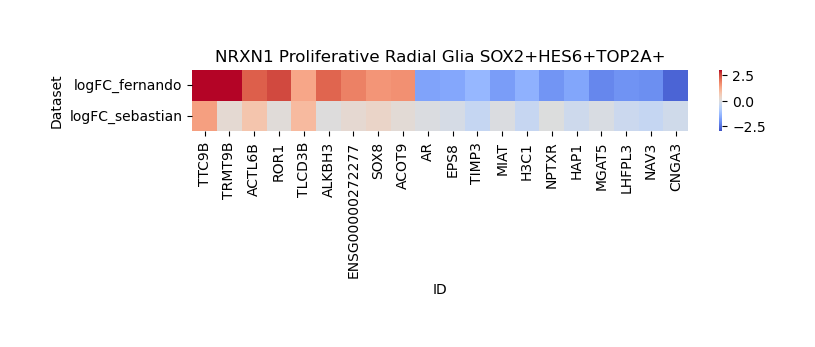

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


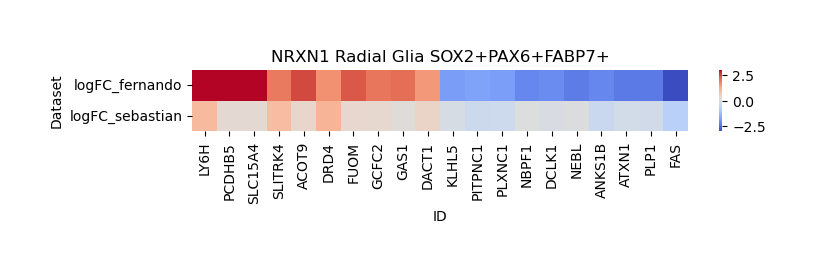

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


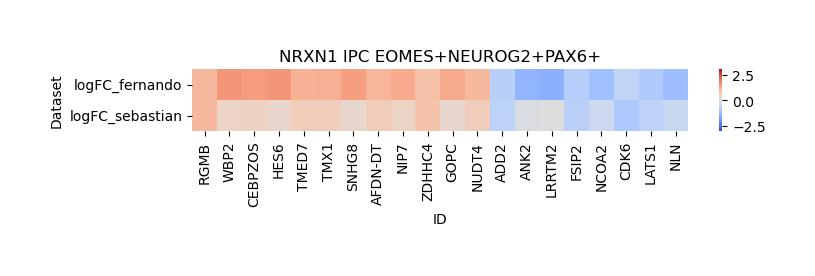

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


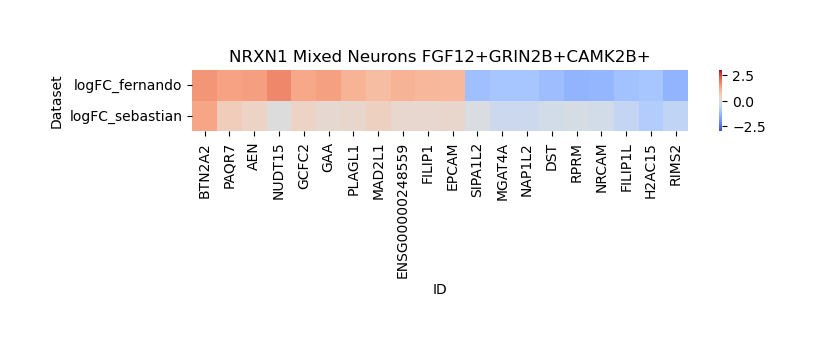

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


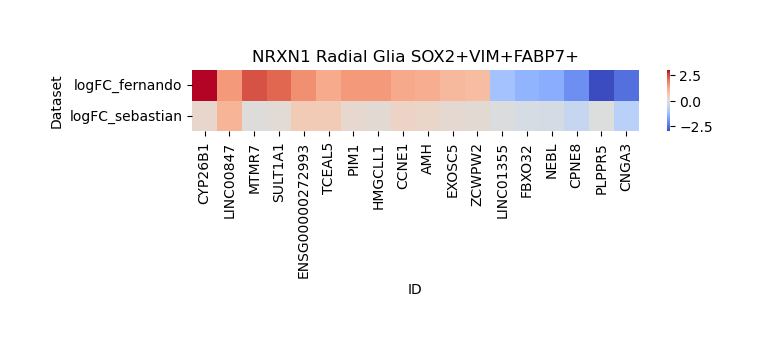

In [21]:
plot_celltype_heatmaps(dc_significant_nrxn1_df_logfc, dataset_label='NRXN1', transpose=True, save=True,
                       value_cols=('logFC_fernando', 'logFC_sebastian'))

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


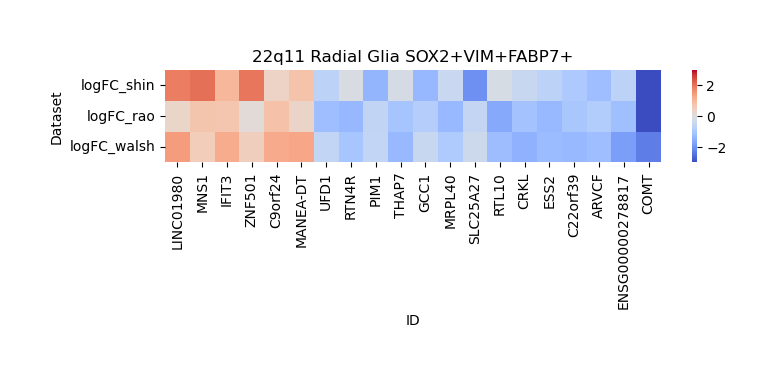

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


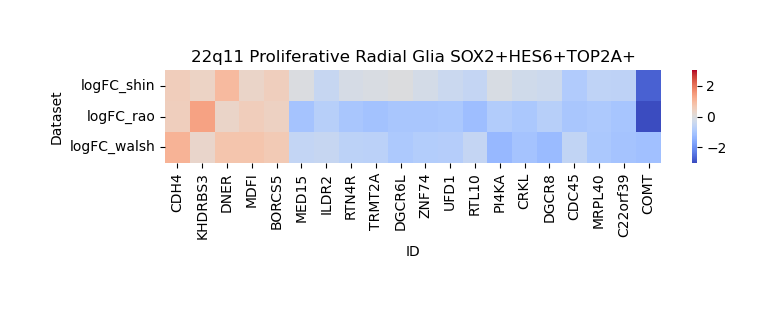

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


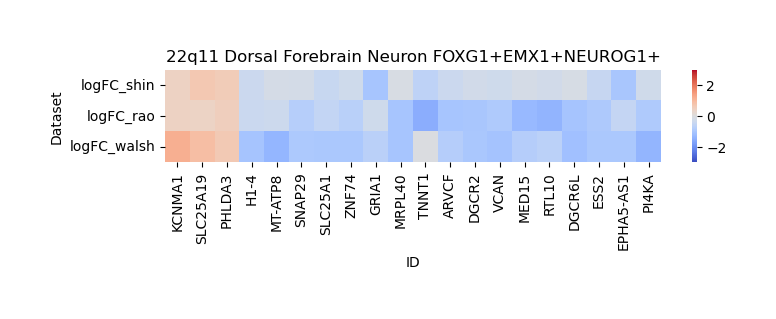

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


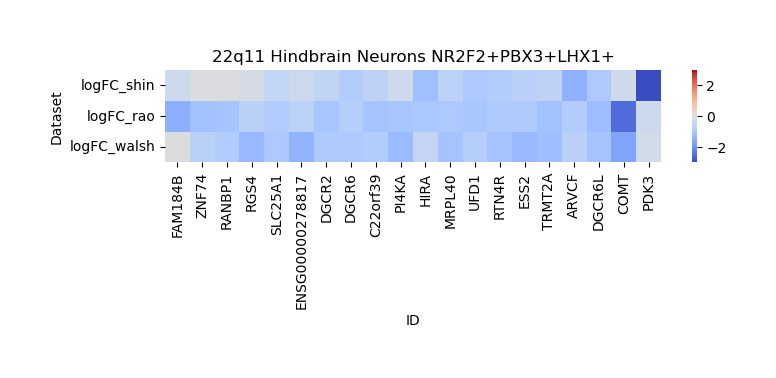

In [22]:
plot_celltype_heatmaps(dc_significant_22q11_df_logfc, transpose=True, save=True,
                       dataset_label="22q11", 
                       value_cols=('logFC_shin', 'logFC_rao', 'logFC_walsh'))

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


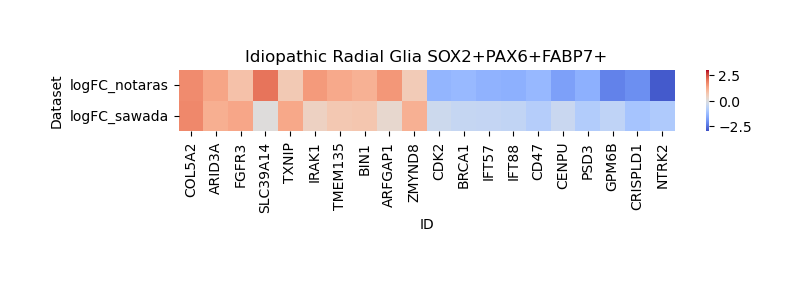

/tmp/ipykernel_358016/1581838489.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


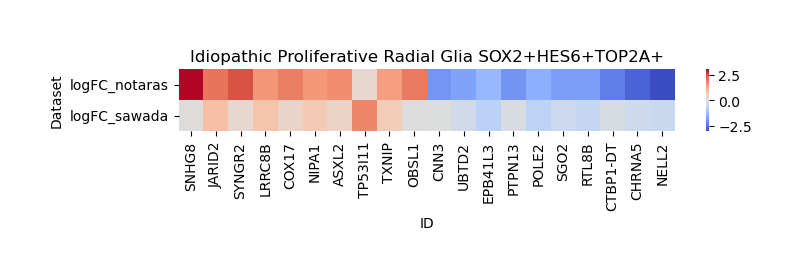

In [23]:
plot_celltype_heatmaps(dc_significant_idiopathic_df_logfc, dataset_label="Idiopathic", transpose=True, save=True,
                       value_cols=('logFC_notaras', 'logFC_sawada'))

In [24]:
dc_significant_idiopathic_df_logfc['assay'].unique()

array(['Radial Glia SOX2+PAX6+FABP7+',
       'Proliferative Radial Glia SOX2+HES6+TOP2A+',
       'Hindbrain Neurons NR2F2+PBX3+LHX1+',
       'Radial Glia SOX2+VIM+FABP7+'], dtype=object)

In [25]:
def plot_assay_upset(df, assay_col='assay',  gene_col='ID', significance_col='significant_fdr', 
                     min_size=1, dataset_label="", top_graph=True, side_graph=True, title=True, save=False):

    # Filter significant genes (optional but recommended)
    if significance_col in df.columns:
        df = df[df[significance_col] == True]
    
    # Build gene sets per assay
    assay_sets = {assay: set(group[gene_col])  for assay, group in df.groupby(assay_col)}
    
    # Remove very small sets if desired
    assay_sets = {k: v for k, v in assay_sets.items() if len(v) >= min_size}
    
    # Convert to upset format
    upset_data = from_contents(assay_sets)
    
    # Plot
    plt.figure(figsize=(10, 6))

    if top_graph and side_graph:
        upset = UpSet(upset_data, show_counts=True, sort_by='degree')
    elif top_graph and not side_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, totals_plot_elements=0)
    elif side_graph and not top_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=())
    elif not top_graph and not side_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=(), totals_plot_elements=0)
    
    upset.plot()

    if title != None:
        title = f"{dataset_label} Shared DGEs"
        plt.suptitle(title)
        
    if save:
        plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_3_{dataset_label}_upset.svg")
    

    plt.show()

In [26]:
def plot_count_strip(values, orientation="horizontal", cmap="Reds", dataset_label='',
                     annotate=True, vmin=None, vmax=None, cbar=True, save=False):
    
    values = np.array(values)
   
    if orientation == "horizontal":

        figsize = (len(values)*1.2857142857142858,1)
        
        data = values.reshape(1, -1)
        xticklabels = False
        yticklabels = False
        
    elif orientation == "vertical":

        figsize=(1*1.2857142857142858, len(values))
        
        data = values.reshape(-1, 1)
        xticklabels = False
        yticklabels = False

    else:
        raise ValueError("orientation must be 'horizontal' or 'vertical'")

    plt.figure(figsize=figsize)
    
    sns.heatmap(data, cmap=cmap, cbar=cbar, annot=annotate, fmt=".0f", xticklabels=xticklabels, 
                yticklabels=yticklabels, vmin=vmin, vmax=vmax)
    
    # plt.tight_layout()
    
    if save:
        plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_3_{dataset_label}_{orientation}_upset_heatmap.svg")
    
    plt.show()

In [27]:
dge_15q13['significant_fdr'] = (dge_15q13['adj.P.Val'] < 0.05)
dge_3q29['significant_fdr'] = (dge_3q29['adj.P.Val'] < 0.05)

In [28]:
# plot_assay_upset(dge_15q13, dataset_label="15q13")

<Figure size 1000x600 with 0 Axes>

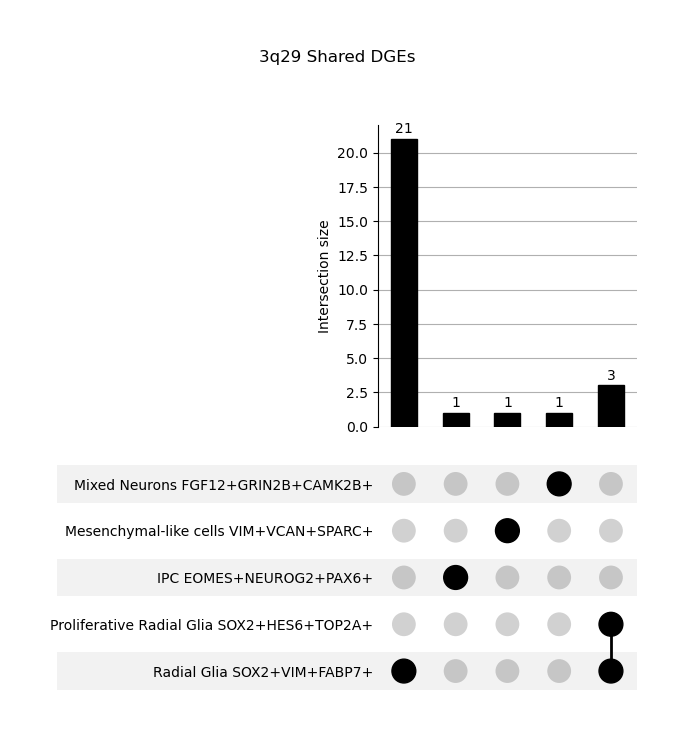

In [29]:
plot_assay_upset(dge_3q29, dataset_label="3q29", top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

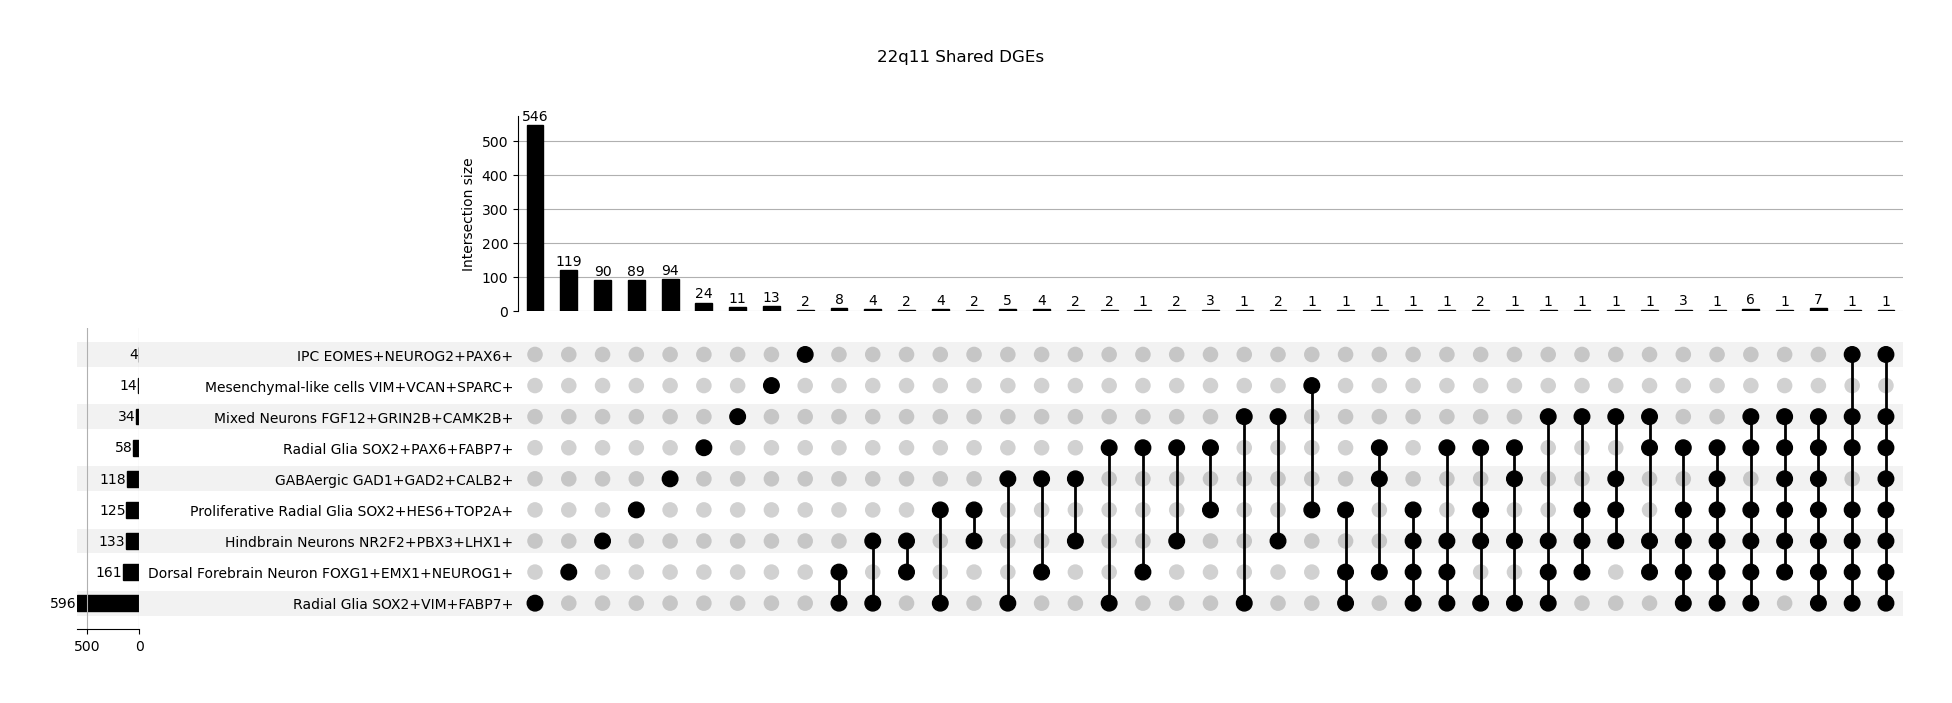

In [30]:
plot_assay_upset(dge_22q11, dataset_label="22q11")

In [31]:
# plot_assay_upset(dc_significant_22q11_df_logfc, dataset_label="22q11")

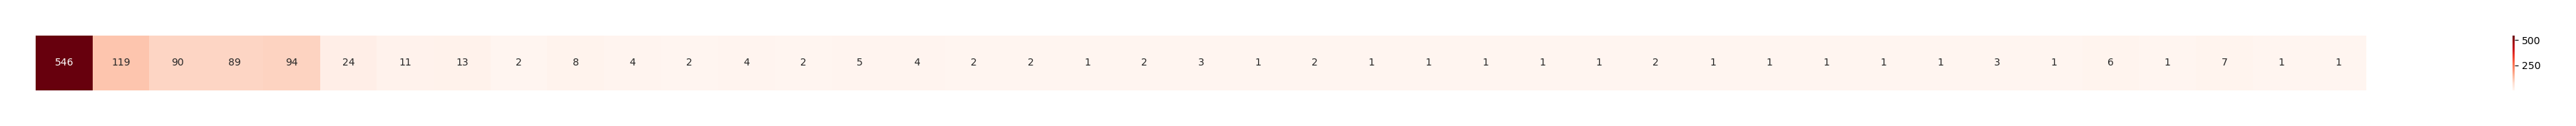

In [32]:
plot_count_strip([546, 119, 90, 89, 94, 24, 11, 13, 2, 8, 4, 2, 4, 2, 5, 4, 2, 2,
                  1, 2, 3, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 3, 1, 6, 1, 7, 1, 1],  
                 dataset_label="22q11", save=True)

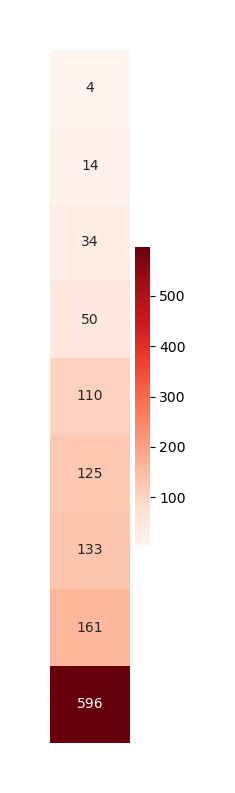

In [33]:
plot_count_strip([4, 14, 34, 50, 110, 125, 133, 161, 596], orientation='vertical', dataset_label="22q11", save=True)

<Figure size 1000x600 with 0 Axes>

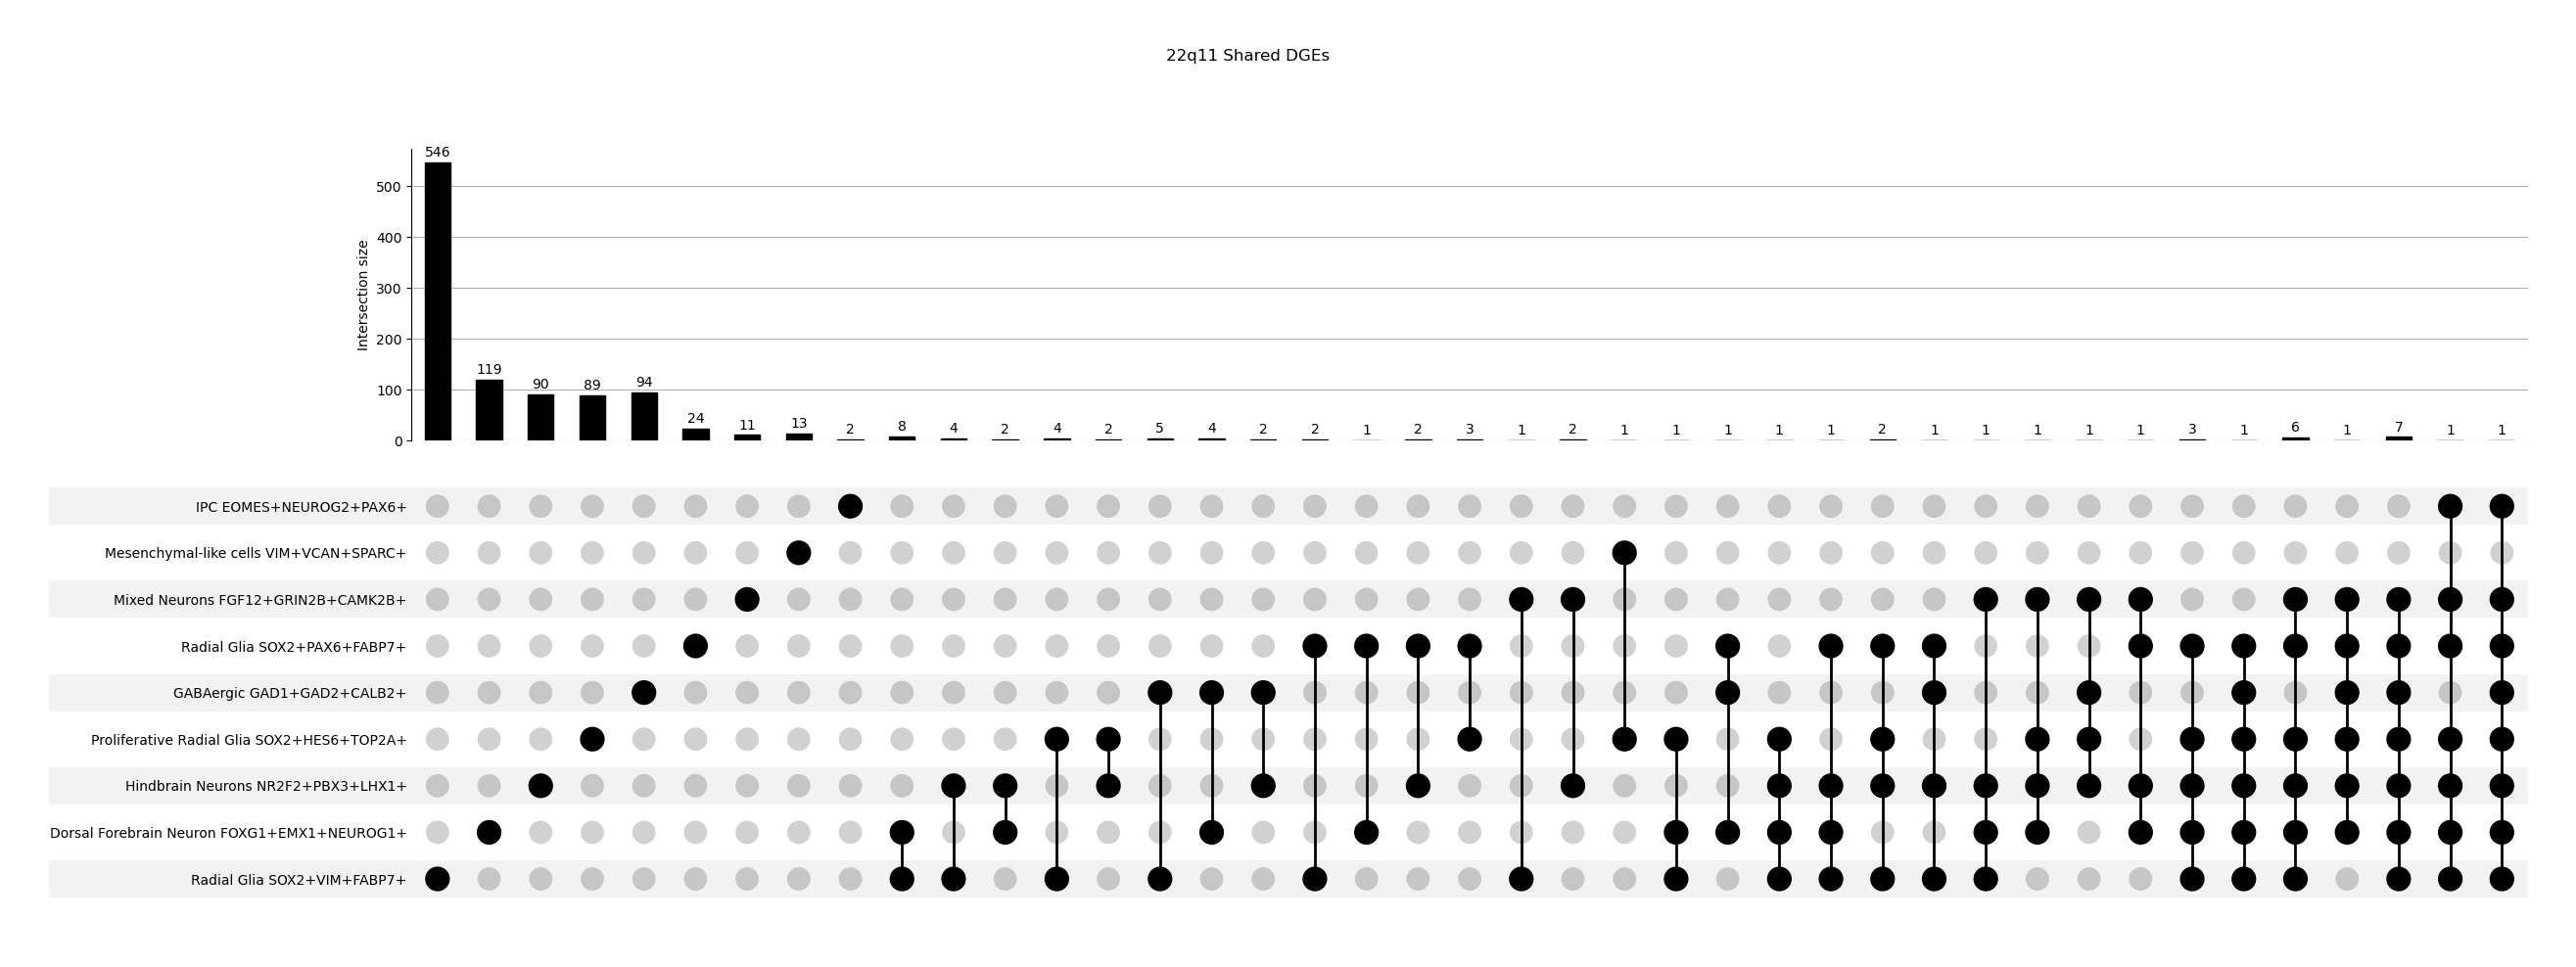

In [34]:
plot_assay_upset(dge_22q11, top_graph=True, side_graph=False, dataset_label="22q11", save=True)

<Figure size 1000x600 with 0 Axes>

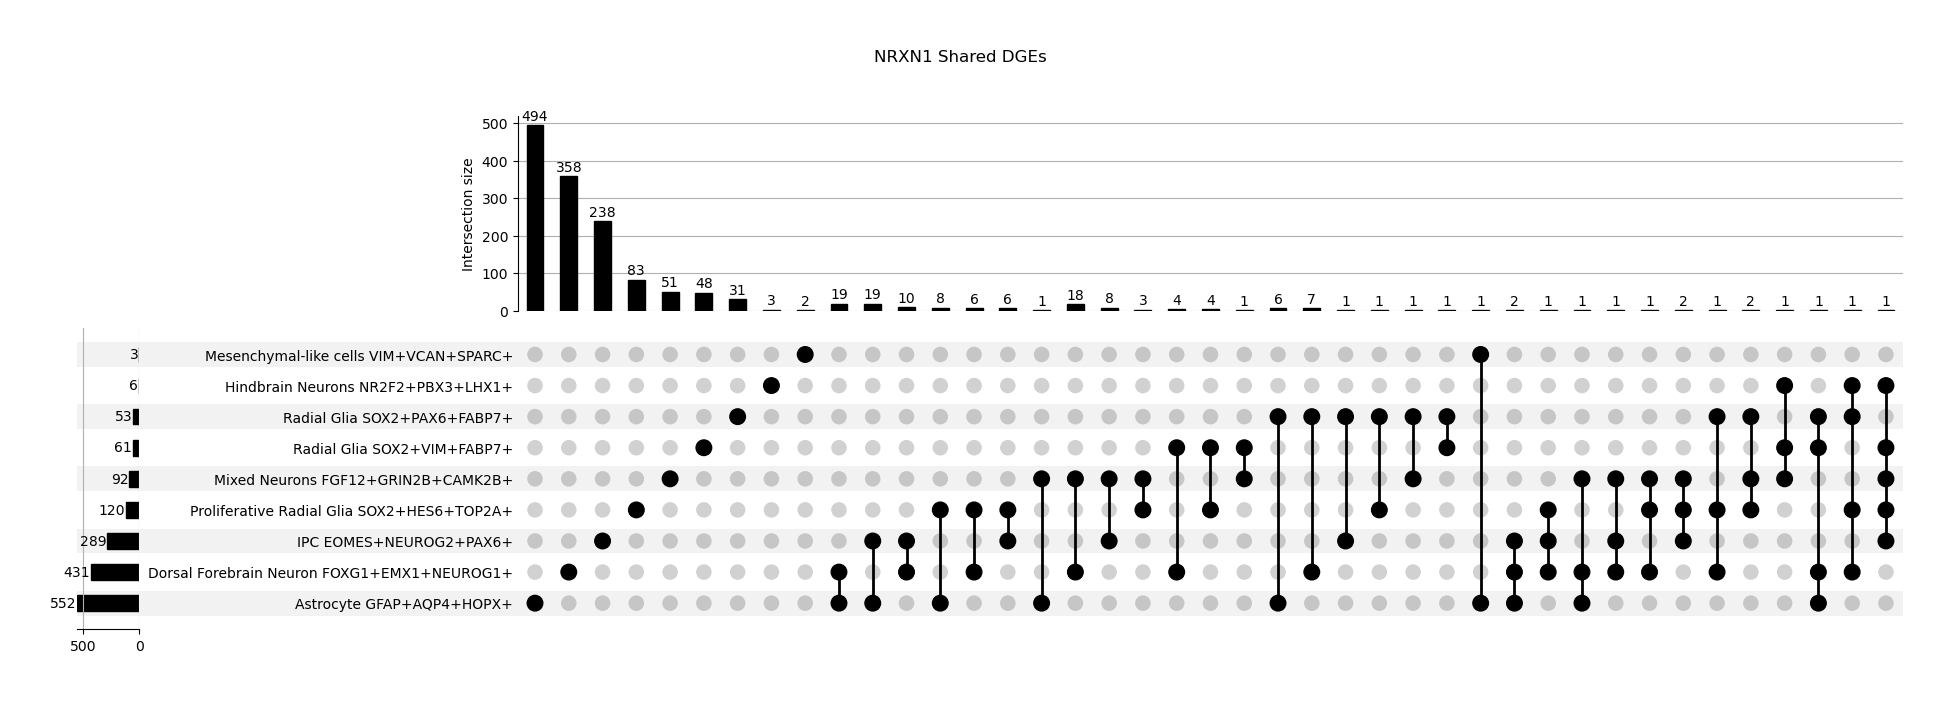

In [35]:
plot_assay_upset(dge_nrxn1, dataset_label="NRXN1")

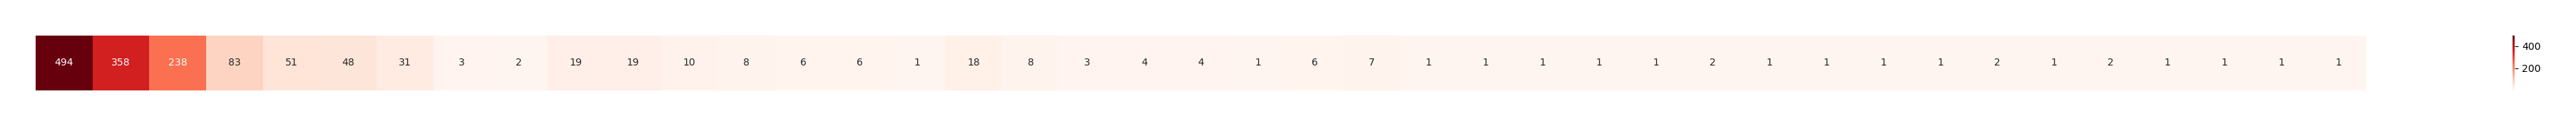

In [36]:
plot_count_strip([494, 358, 238, 83, 51, 48, 31, 3, 2, 19, 19, 10,
                  8, 6, 6, 1, 18, 8, 3,   4, 4, 1, 6, 7, 1, 1, 1, 
                  1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1], orientation='horizontal', dataset_label="NRXN1", save=True)

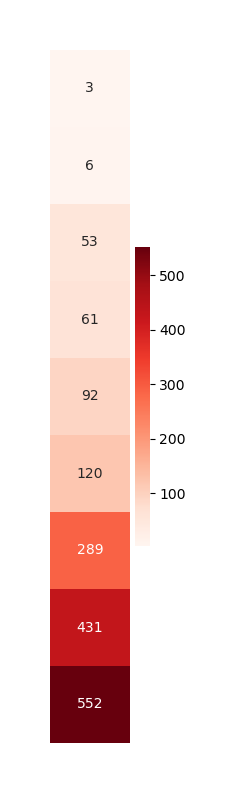

In [37]:
plot_count_strip([3, 6, 53, 61, 92, 120, 289, 431, 552], orientation='vertical', dataset_label="NRXN1", save=True)

In [38]:
# plot_assay_upset(dge_nrxn1, top_graph=True, side_graph=False, dataset_label="NRXN1_w_top_graph", save=True)

<Figure size 1000x600 with 0 Axes>

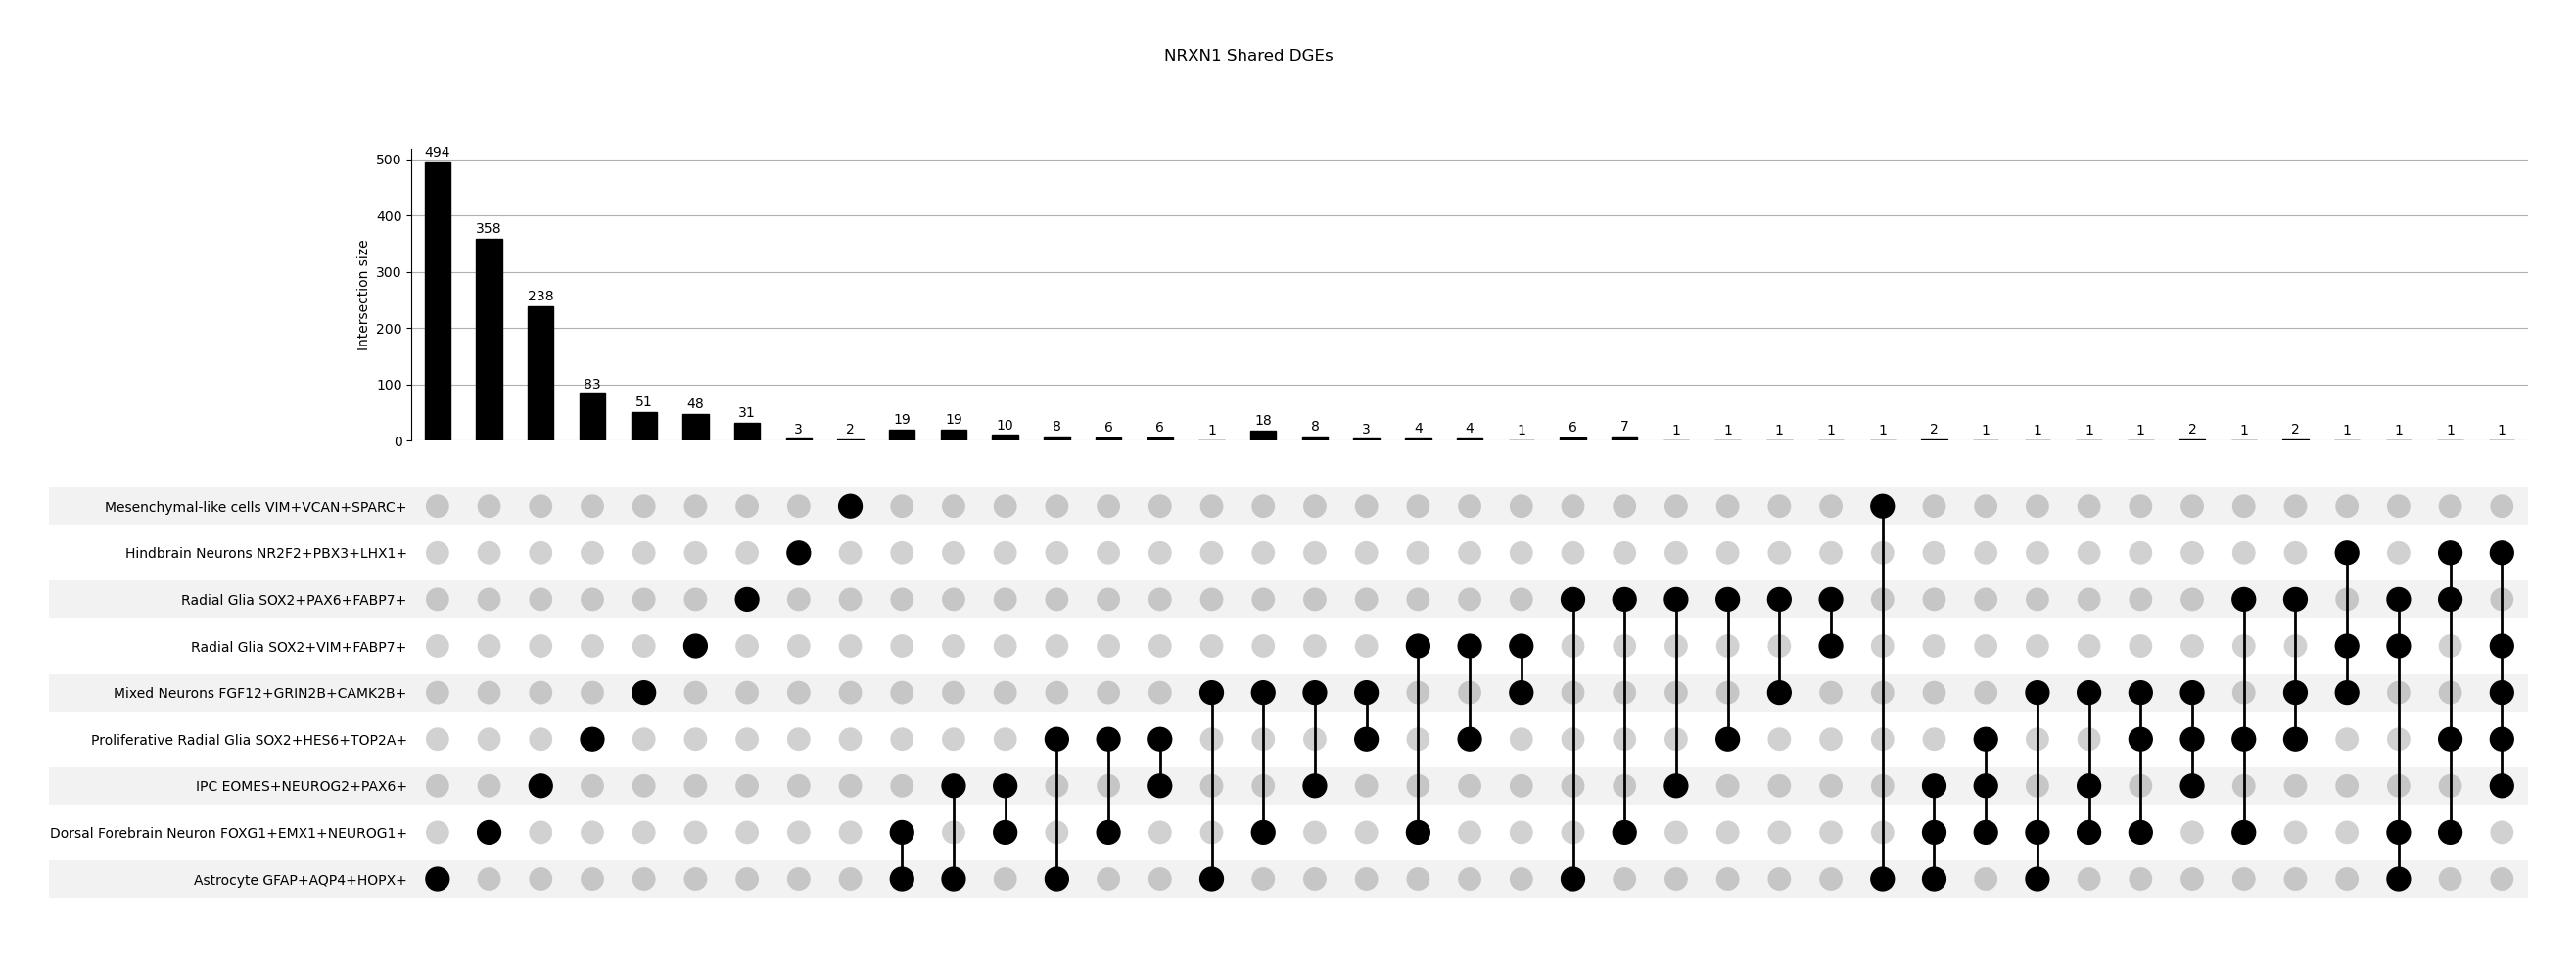

In [39]:
plot_assay_upset(dge_nrxn1, top_graph=True, side_graph=False, dataset_label="NRXN1", save=True)

<Figure size 1000x600 with 0 Axes>

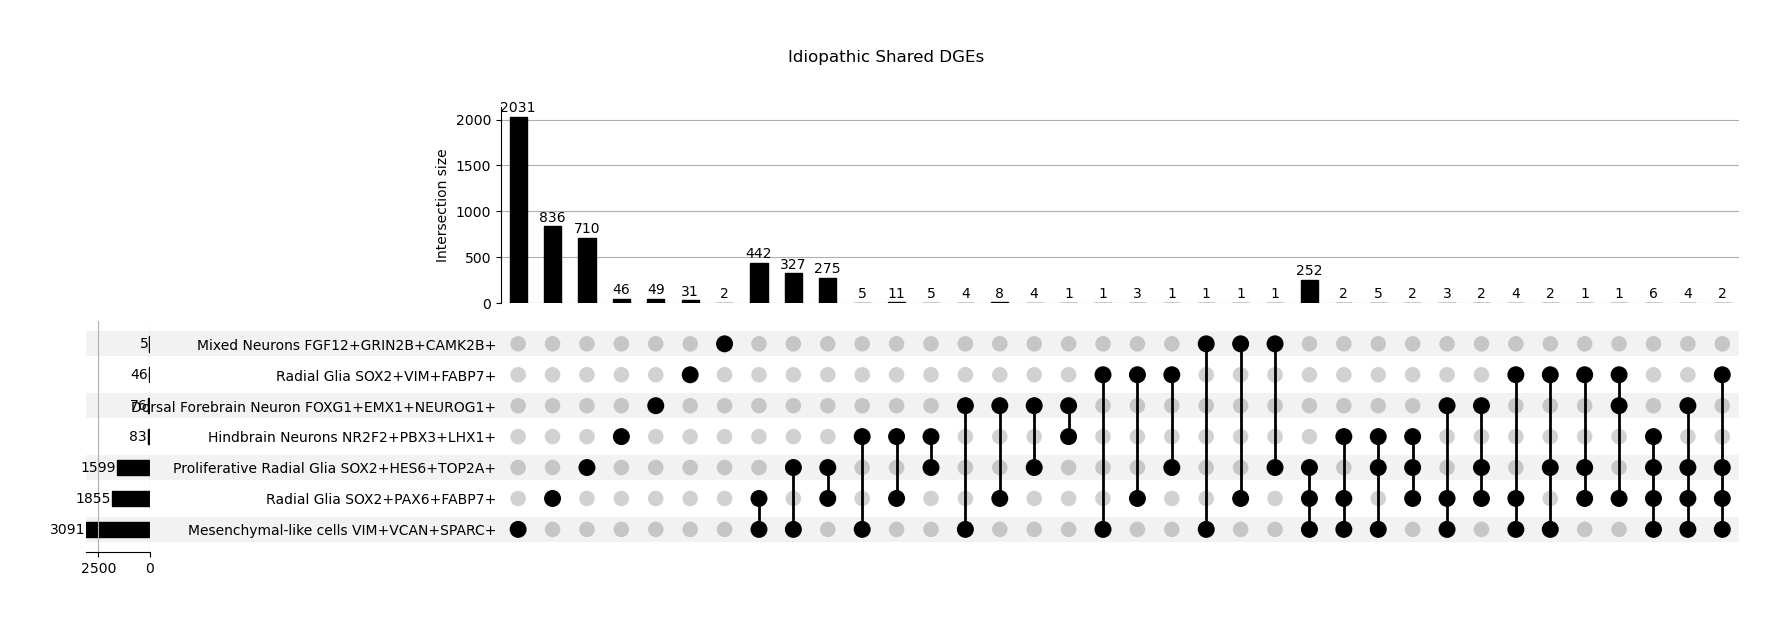

In [40]:
plot_assay_upset(dge_idiopathic, dataset_label="Idiopathic")

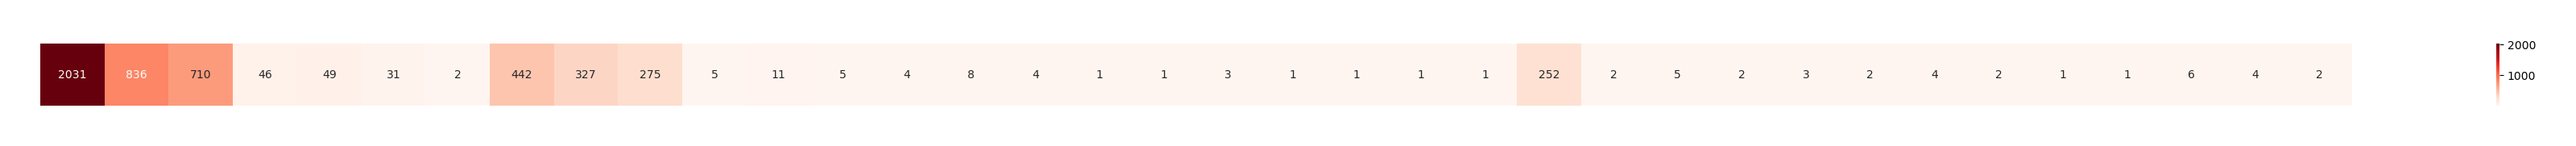

In [41]:
plot_count_strip([2031, 836, 710, 46, 49, 31, 2, 442, 327, 275, 5, 11, 5, 4, 8, 4, 1, 1, 3, 1, 1, 1, 1, 252, 2, 5, 2, 3, 2, 4, 2,
                  1, 1, 6, 4, 2], orientation='horizontal', dataset_label="Idiopathic", save=True)

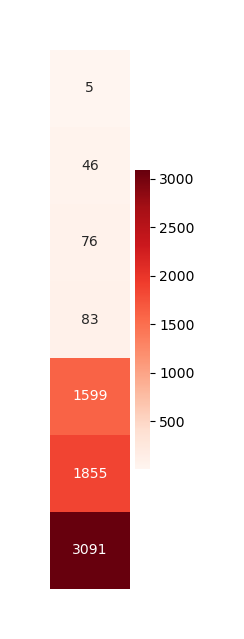

In [42]:
plot_count_strip([5, 46, 76, 83, 1599, 1855, 3091], orientation='vertical', dataset_label="Idiopathic", save=True)

In [43]:
# plot_assay_upset(dc_significant_idiopathic_df_logfc, top_graph=True, side_graph=False, dataset_label="Idiopathic_w_top_graph", save=True)

<Figure size 1000x600 with 0 Axes>

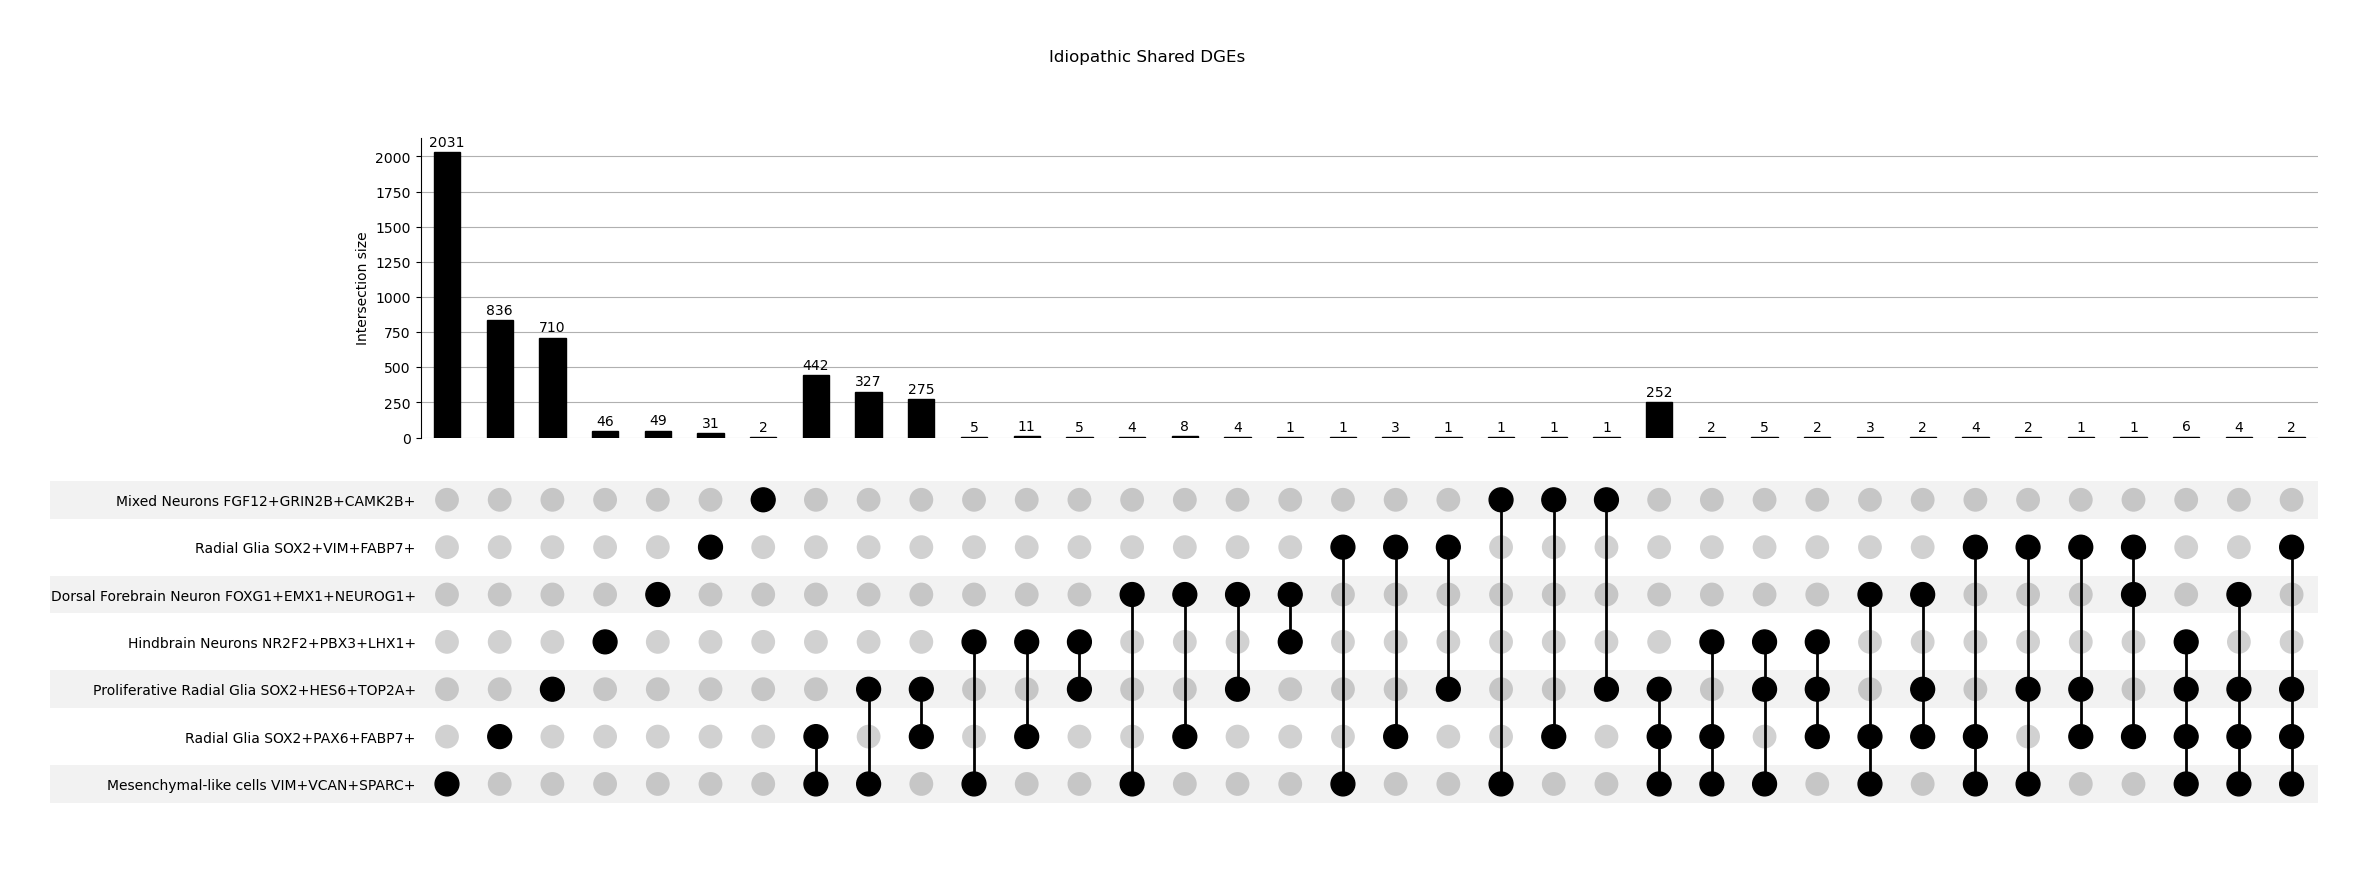

In [44]:
plot_assay_upset(dge_idiopathic, top_graph=True, side_graph=False, dataset_label="Idiopathic", save=True)

In [45]:
def plot_disease_circos(df, title=None, min_genes=1, cmap="tab10", save=False):

    df = df.copy()

    # 1. Node = assay (cell type only)
    nodes = df["assay"].unique()

    # # 2. Filter 
    df = df[df["significant_fdr"] == True]
    # df = df[df["directionally_consistent"] == True]

    # 3. Gene sets per cell type
    gene_sets = {node: set(sub["ID"])    for node, sub in df.groupby("assay")}

    # optionally remove empty nodes
    gene_sets = {k: v for k, v in gene_sets.items() if len(v) >= min_genes}

    nodes = list(gene_sets.keys())

    # 4. Build overlap matrix
    matrix = pd.DataFrame(0, index=nodes, columns=nodes)

    for i in range(len(nodes)):
        for j in range(len(nodes)):
    
            if i == j:
                continue
    
            a, b = nodes[i], nodes[j]
    
            shared = gene_sets[a] & gene_sets[b]
    
            value = len(shared)
    
            matrix.loc[a, b] = value
            matrix.loc[b, a] = value   

    # 5. Remove empty rows/cols
    matrix = matrix.loc[(matrix.sum(axis=1) > 0), (matrix.sum(axis=0) > 0)]

    # 6. Circos chord diagram
    circos = Circos.chord_diagram(
        matrix,
        space=2,
        r_lim=(92, 100),
        cmap=cmap,
        ticks_interval=None,
        label_kws=dict(size=9, r=94))

    if title:
        circos.text(title, r=1.2, size=12)

    fig = circos.plotfig()

    if save:
        plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_3_{title}_circos.svg")

In [46]:
color_map = {
    # Astrocyte (muted purple)
    "Astrocyte GFAP+AQP4+HOPX+": "#9467bd", 

    # Excitatory / forebrain neurons (blues / lavenders)
    "Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+": "#1f77b4",
    "Mixed Neurons FGF12+GRIN2B+CAMK2B+": "#bebada",

    # IPC (muted orange)
    "IPC EOMES+NEUROG2+PAX6+": "#fdb462", 

    # Radial glia / progenitors (cyan / teal / pink family)
    "Radial Glia SOX2+VIM+FABP7+": "#17becf",
    "Radial Glia SOX2+PAX6+FABP7+": "#80b1d3",
    "Proliferative Radial Glia SOX2+HES6+TOP2A+": "#e377c2",

    # Oligodendrocyte lineage (seafoam / muted green)
    "OPC OLIG1+OLIG2+PDGFRA+": "#8dd3c7",
    "Oligodendrocyte OLIG1+OLIG2+MBP+": "#4daf4a",

    # Inhibitory / hindbrain neurons (greens)
    "GABAergic GAD1+GAD2+CALB2+": "#b3de69",
    "Hindbrain Neurons NR2F2+PBX3+LHX1+": "#2ca02c",

    # Mesenchymal (olive / distinct)
    "Mesenchymal-like cells VIM+VCAN+SPARC+": "#bcbd22",
}

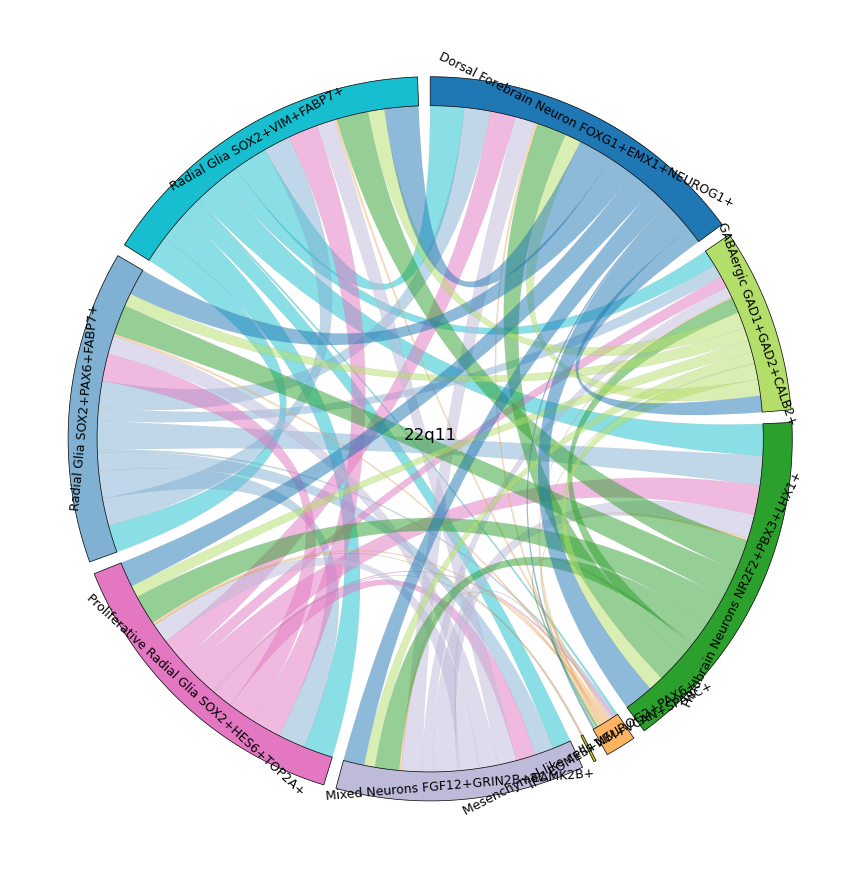

In [47]:
plot_disease_circos(dge_22q11, title="22q11", save=True, cmap=color_map)

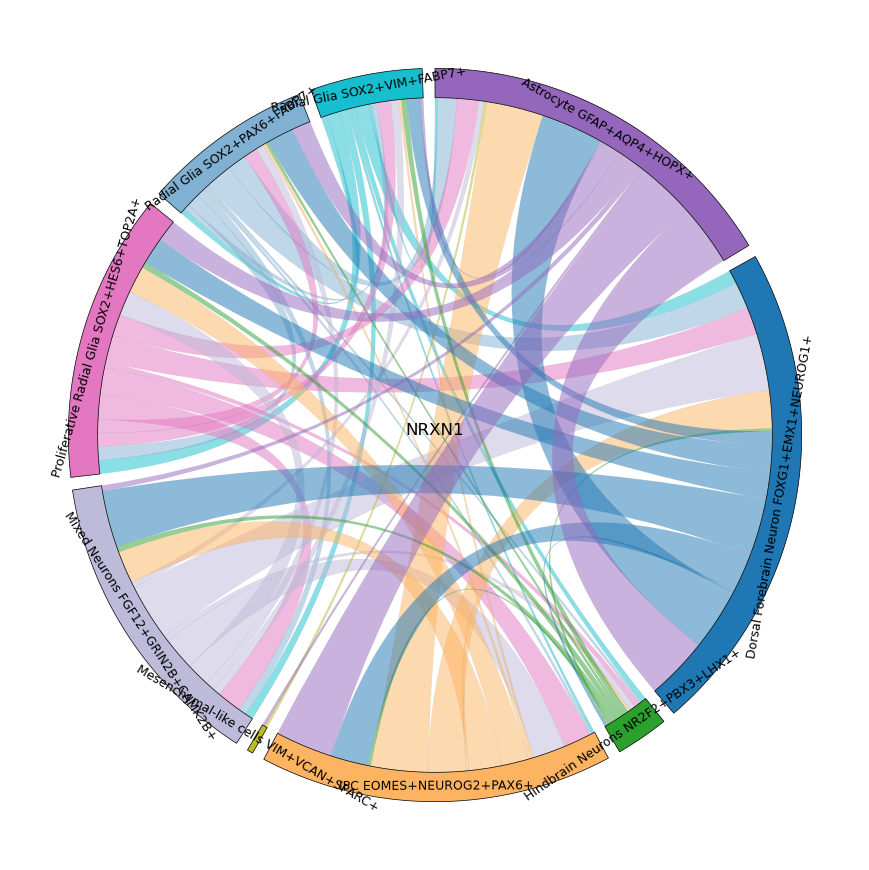

In [48]:
plot_disease_circos(dge_nrxn1, title="NRXN1", save=True, cmap=color_map)

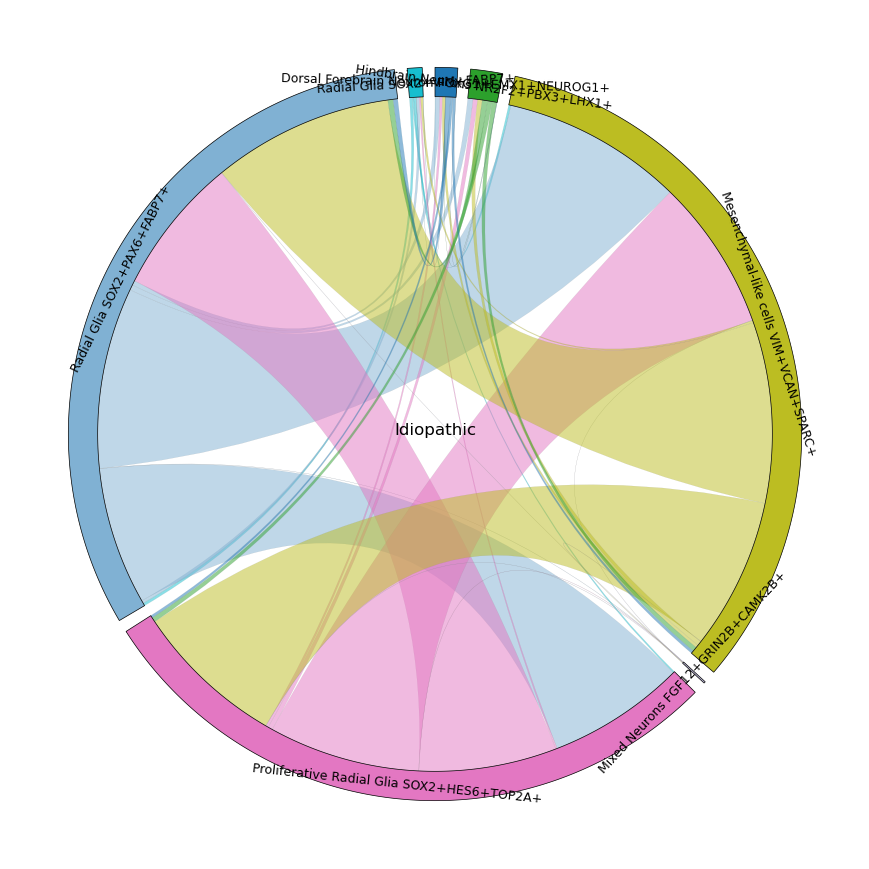

In [49]:
plot_disease_circos(dge_idiopathic, title="Idiopathic", save=True, cmap=color_map)